# Análise e Predição de Preços de Imóveis de São Paulo

## Introdução

Este projeto surgiu da minha iniciativa em aplicar, na prática, os conhecimentos adquiridos durante o curso de Análise de Dados da Programaria. Com o objetivo de consolidar os conceitos estudados ao longo da formação, escolhi desenvolver um projeto com o tema: o mercado imobiliário. A proposta consiste em analisar um conjunto de dados de imóveis da cidade de São Paulo, explorando informações relacionadas às características dos imóveis e seus valores de venda.

Ao longo do projeto, serão aplicados conceitos de análise exploratória de dados, estatística, banco de dados, visualização de informações e aprendizado de máquina, seguindo um fluxo completo de análise de dados. Além de reforçar o aprendizado obtido no curso, este projeto busca demonstrar minha capacidade de transformar conhecimento teórico em uma aplicação prática, desenvolvendo soluções orientadas por dados para compreender padrões do mercado e construir modelos capazes de estimar o preço de imóveis com base em suas características.


### Definição do Problema de Negócio


**Objetivo:** Identificar quais fatores influenciam o preço dos imóveis em São Paulo e construir um modelo capaz de estimar esse valor.

**Perguntas:**
1.   A localização influencia o preço?
2.   Imóveis maiores custam proporcionalmente mais?
3.   Quantos quartos, banheiros e vagas impactam o valor?
4.   É possível prever o preço de venda apenas pelas características do imóvel?

## Importações de Bibliotecas

In [93]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


## Lendo Dado da Planilha

In [3]:
dados = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/csvprojeto/sao-paulo-properties-april-2019.csv')

## Entendendo a Planilha

In [4]:
# Colunas
dados.columns

Index(['Price', 'Condo', 'Size', 'Rooms', 'Toilets', 'Suites', 'Parking',
       'Elevator', 'Furnished', 'Swimming Pool', 'New', 'District',
       'Negotiation Type', 'Property Type', 'Latitude', 'Longitude'],
      dtype='object')

In [5]:
# Comportamento
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13640 entries, 0 to 13639
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             13640 non-null  int64  
 1   Condo             13640 non-null  int64  
 2   Size              13640 non-null  int64  
 3   Rooms             13640 non-null  int64  
 4   Toilets           13640 non-null  int64  
 5   Suites            13640 non-null  int64  
 6   Parking           13640 non-null  int64  
 7   Elevator          13640 non-null  int64  
 8   Furnished         13640 non-null  int64  
 9   Swimming Pool     13640 non-null  int64  
 10  New               13640 non-null  int64  
 11  District          13640 non-null  object 
 12  Negotiation Type  13640 non-null  object 
 13  Property Type     13640 non-null  object 
 14  Latitude          13640 non-null  float64
 15  Longitude         13640 non-null  float64
dtypes: float64(2), int64(11), object(3)
memo

Podemos ver acima que nenhum dos atributos tem valores nulos ou ausentes.

In [6]:
# Primeiras Linhas
dados.head()

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,District,Negotiation Type,Property Type,Latitude,Longitude
0,930,220,47,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.543138,-46.479486
1,1000,148,45,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.550239,-46.480718
2,1000,100,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.542818,-46.485665
3,1000,200,48,2,2,1,1,0,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.547171,-46.483014
4,1300,410,55,2,2,1,1,1,0,0,0,Artur Alvim/São Paulo,rent,apartment,-23.525025,-46.482436


      Qual. Ord.   Qual. Nom.           Quant. Cont.    Quant. Disc.
                   District             Price           Rooms
                   Negotiation Type     Condo           Toilets
                   Property Type         Size            Suites
                                                        Parking
                                                        Elevator
                                                        Furnished
                                                        Swimming Pool
                                                        New

In [7]:
numericas = [
    'Price', 'Condo', 'Size',
    'Rooms', 'Toilets',
    'Suites', 'Parking'
]

categoricas = [
    'District',
    'Negotiation Type',
    'Property Type',
    'Elevator',
    'Furnished',
    'Swimming Pool',
    'New'
]

todas = numericas + categoricas

In [8]:
# Alguns detalhes dos dados
dados.describe()

,Price,Condo,Size,Rooms,Toilets,Suites,Parking,Elevator,Furnished,Swimming Pool,New,Latitude,Longitude
count,1.364000e+04,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.000000,13640.00000,13640.000000,13640.000000,13640.000000
mean,2.877378e+05,689.882331,84.373900,2.312023,2.073680,0.980792,1.393182,0.354179,0.146774,0.51217,0.015616,-22.077047,-43.597088
std,5.908214e+05,757.649363,58.435676,0.777461,0.961803,0.834891,0.829932,0.478281,0.353894,0.49987,0.123988,5.866633,11.487288
min,4.800000e+02,0.000000,30.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,-46.749039,-58.364352
25%,1.858750e+03,290.000000,50.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,0.00000,0.000000,-23.594552,-46.681671
50%,8.100000e+03,500.000000,65.000000,2.000000,2.000000,1.000000,1.000000,0.000000,0.000000,1.00000,0.000000,-23.552813,-46.637255
75%,3.600000e+05,835.000000,94.000000,3.000000,2.000000,1.000000,2.000000,1.000000,0.000000,1.00000,0.000000,-23.517640,-46.560040
max,1.000000e+07,9500.000000,880.000000,10.000000,8.000000,6.000000,9.000000,1.000000,1.000000,1.00000,1.000000,0.000000,0.000000


In [9]:
# Detalhes dos dados qualitativos
dados.describe(include=object)

,District,Negotiation Type,Property Type
count,13640,13640,13640
unique,96,2,1
top,Moema/São Paulo,rent,apartment
freq,293,7228,13640


A partir das análises anteriores, observa-se que a maior parte dos imóveis disponíveis está destinada à locação. Além disso, há uma considerável diversidade nas características dos imóveis, especialmente em relação à quantidade de quartos e banheiros, indicando a presença de diferentes perfis de moradia no conjunto de dados. Nas próximas seções irei abordar isso de forma detalhada.

## Análise Exploratória

Como os preços de aluguel e venda possuem escalas muito diferentes, as análises serão realizadas separadamente para evitar interpretações equivocadas.

In [10]:
dados['Negotiation Type'].value_counts(normalize=bool)

,proportion
Negotiation Type,
rent,0.529912
sale,0.470088


Embora os imóveis para aluguel sejam maioria, observa-se que a diferença em relação aos imóveis à venda não é expressiva. Os imóveis classificados como "rent" representam 52,99% da base de dados, enquanto os classificados como "sale" correspondem a 47,01%, indicando uma distribuição relativamente equilibrada entre as duas categorias.

In [11]:
# Quantidade de imóveis por bairro
dados['District'].value_counts()

,count
District,
Moema/São Paulo,293
Mooca/São Paulo,288
Brás/São Paulo,255
Brooklin/São Paulo,250
Bela Vista/São Paulo,250
...,...
São Rafael/São Paulo,44
Jardim São Luis/São Paulo,44
Grajaú/São Paulo,37


### Distribuição

Análise dos imóveis para alugar

In [12]:
media_aluguel = np.mean(dados[dados['Negotiation Type']=='rent']['Price'])
print(f'A média dos valores de aluguel é R$ {media_aluguel}')

A média dos valores de aluguel é R$ 3077.6690647482014


In [13]:
mediana_aluguel = np.median(dados[dados['Negotiation Type']=='rent']['Price'])
print(f'A mediana dos valores de aluguel é R$ {mediana_aluguel}')

A mediana dos valores de aluguel é R$ 2000.0


A média dos valores de aluguel é superior à mediana, sugerindo a presença de imóveis com valores muito elevados que puxam a média para cima. Esse comportamento indica uma distribuição assimétrica à direita.

In [14]:
# Qual o imóvel mais caro para alugar
dados[dados['Negotiation Type'] == 'rent']['Price'].max()

50000

In [15]:
# Em qual bairro fica?
dados.loc[
    dados[dados['Negotiation Type']=='rent']['Price'].idxmax()
]

,1589
Price,50000
Condo,6800
Size,598
Rooms,4
Toilets,7
Suites,4
Parking,6
Elevator,1
Furnished,0
Swimming Pool,1


Encontramos que o imóvel mais caro para alugar é RS 50.000,00 mensais e fica em Alto de Pinheiros.

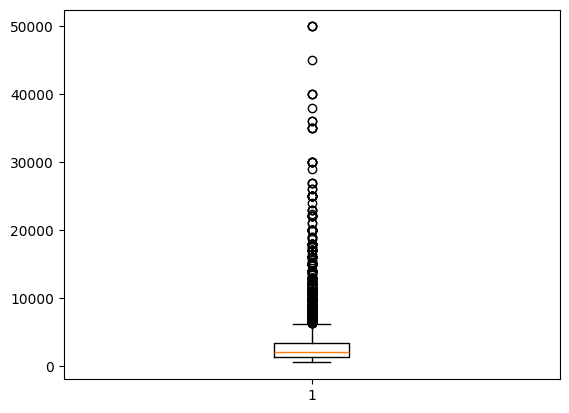

In [16]:
plt.boxplot(dados[dados['Negotiation Type'] == 'rent']['Price'])
plt.show()

Análise dos imóveis para vender

In [17]:
media_venda = np.mean(dados[dados['Negotiation Type']=='sale']['Price'])
print(f'A média dos valores de venda é R$ {media_venda}')

A média dos valores de venda é R$ 608624.1400499064


In [18]:
mediana_venda = np.median(dados[dados['Negotiation Type']=='sale']['Price'])
print(f'A mdiana dos valores de venda é R$ {mediana_venda}')

A mdiana dos valores de venda é R$ 380000.0


Aqui também vemos uma grande diferença entre a média dos valores de venda e mediana, sugerindo a presença de imóveis com valores muito elevados que puxam a média para cima. Esse comportamento indica uma distribuição assimétrica à direita.

In [19]:
# Qual o imóvel mais caro para venda
dados[dados['Negotiation Type'] == 'sale']['Price'].max()

10000000

In [20]:
# Onde fica?
dados.loc[
    dados[dados['Negotiation Type']=='sale']['Price'].idxmax()
]

,6282
Price,10000000
Condo,0
Size,343
Rooms,4
Toilets,7
Suites,4
Parking,5
Elevator,0
Furnished,0
Swimming Pool,0


Encontramos que o imóvel mais caro para vender é RS 1.000.000,00 e fica em Iguatemi.

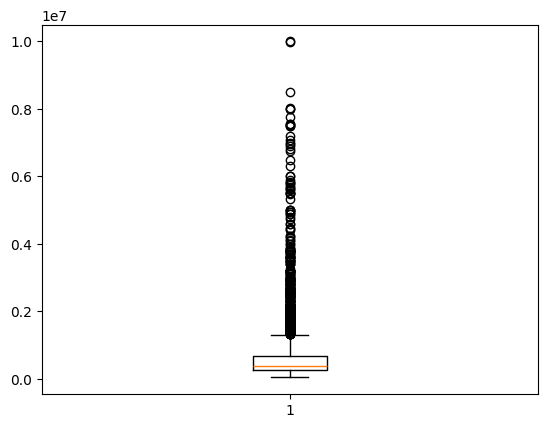

In [21]:
plt.boxplot(dados[dados['Negotiation Type'] == 'sale']['Price'])
plt.show()

Os boxplots dos preços de aluguel e venda evidenciam uma distribuição altamente assimétrica, caracterizada pela presença de muitos outliers. Em ambos os casos, a maior parte dos imóveis concentra-se em faixas de preço relativamente menores, enquanto um pequeno grupo de imóveis de alto padrão apresenta valores significativamente superiores aos demais.

No mercado de locação, observa-se que a maior parte dos imóveis possui preços relativamente concentrados, porém existem imóveis com aluguéis que ultrapassam R$ 50.000 mensais. Esses valores extremos elevam a média dos preços e indicam a presença de imóveis de alto padrão na base de dados.

O mesmo comportamento é observado no mercado de venda, onde alguns imóveis atingem valores próximos de R$ 10 milhões. A quantidade expressiva de outliers sugere elevada heterogeneidade no mercado imobiliário paulistano, reunindo desde imóveis populares até propriedades de luxo.

### Localidade X Preço

In [22]:
# Análise dos valores de aluguel agrupados por bairros / ordenados do menor pro maior
media_preco_aluguel_bairro = dados[dados['Negotiation Type'] == 'rent'].groupby('District')['Price'].mean().sort_values(ascending=True)
media_preco_aluguel_bairro

,Price
District,
Itaim Paulista/São Paulo,840.416667
Grajaú/São Paulo,925.000000
Lajeado/São Paulo,931.250000
José Bonifácio/São Paulo,944.977273
Guaianazes/São Paulo,970.833333
...,...
Jardim Paulista/São Paulo,7409.914894
Moema/São Paulo,7547.993865
Alto de Pinheiros/São Paulo,7825.766917


In [ ]:
# Mapa de calor geográfico
fig = px.density_mapbox(dados, lat='Latitude', lon='Longitude', z='Price',
                        radius=20,
                        center=dict(lat=-23.55, lon=-46.63), zoom=10.5,
                        mapbox_style="open-street-map")
fig.show()

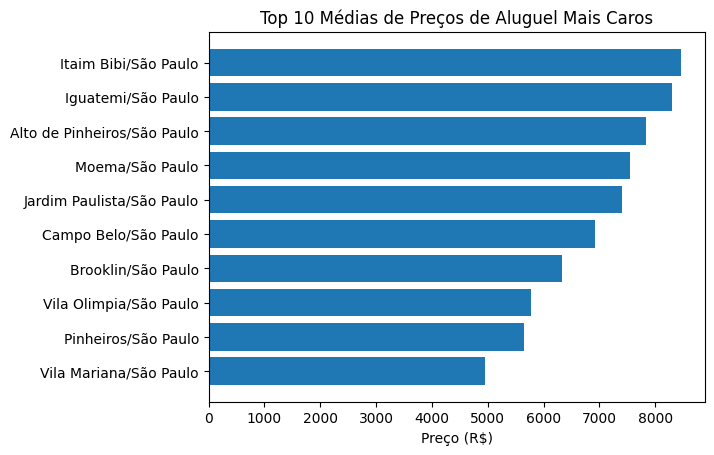

In [23]:
top10rent = media_preco_aluguel_bairro.sort_values(ascending=False).head(10)

plt.figure()
plt.barh(top10rent.index, top10rent.values)
plt.gca().invert_yaxis()

plt.title("Top 10 Médias de Preços de Aluguel Mais Caros")
plt.xlabel("Preço (R$)")

plt.show()

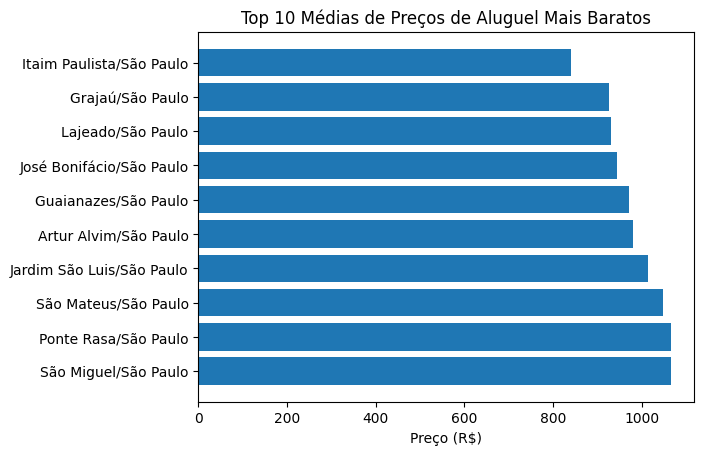

In [24]:
#Mais Baratos
top10rent = media_preco_aluguel_bairro.sort_values(ascending=True).head(10)

plt.figure()
plt.barh(top10rent.index, top10rent.values)
plt.gca().invert_yaxis()

plt.title("Top 10 Médias de Preços de Aluguel Mais Baratos")
plt.xlabel("Preço (R$)")

plt.show()

In [25]:
# Análise dos valores de venda agrupados por bairros / ordenados do menor pro maior
media_preco_venda_bairro  = dados[dados['Negotiation Type'] == 'sale'].groupby('District')['Price'].mean().sort_values(ascending=True)
media_preco_venda_bairro

,Price
District,
Cidade Tiradentes/São Paulo,1.137238e+05
Lajeado/São Paulo,1.714128e+05
Artur Alvim/São Paulo,1.896892e+05
Guaianazes/São Paulo,1.919128e+05
Perus/São Paulo,1.960797e+05
...,...
Moema/São Paulo,1.625677e+06
Jardim Paulista/São Paulo,1.802961e+06
Itaim Bibi/São Paulo,1.858341e+06


Text(0.5, 1.0, 'Top 10 Médias de Preços de Venda Mais Caros')

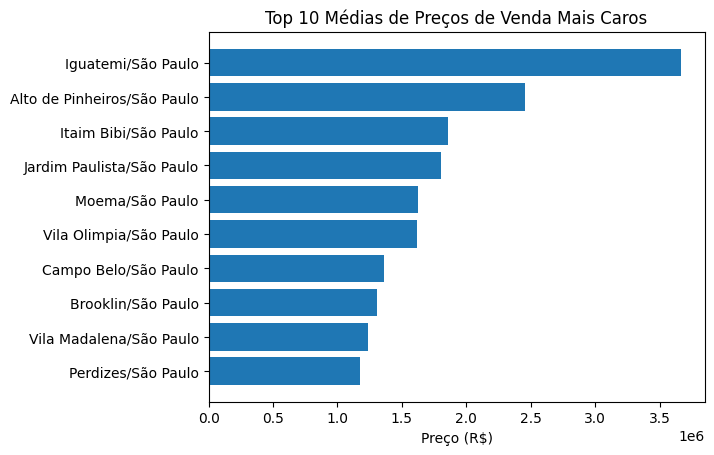

In [26]:
top10sale = media_preco_venda_bairro.sort_values(ascending=False).head(10)

plt.figure()

plt.barh(top10sale.index, top10sale.values)
plt.gca().invert_yaxis()

plt.xlabel("Preço (R$)")
plt.title("Top 10 Médias de Preços de Venda Mais Caros")

Text(0.5, 1.0, 'Top 10 Médias de Preços de Venda Mais Baratos')

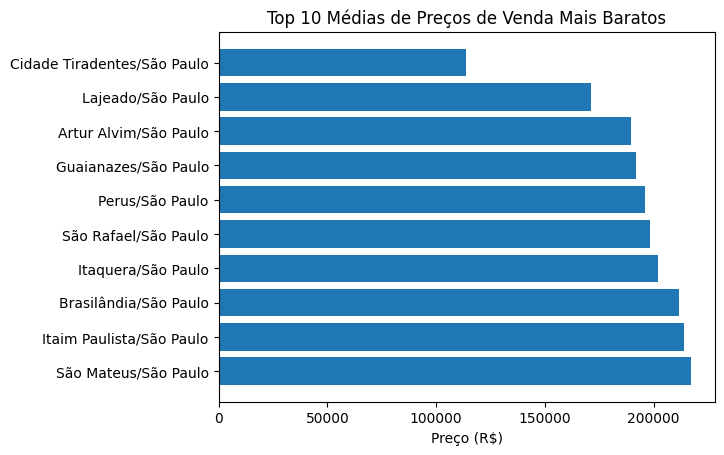

In [27]:
top10sale = media_preco_venda_bairro.sort_values(ascending=True).head(10)

plt.figure()

plt.barh(top10sale.index, top10sale.values)
plt.gca().invert_yaxis()

plt.xlabel("Preço (R$)")
plt.title("Top 10 Médias de Preços de Venda Mais Baratos")

Para os imóveis destinados à locação, os menores valores médios são encontrados em distritos como Itaim Paulista, Grajaú e Lajeado, com aluguéis médios inferiores a RS 1.000,00. Em contrapartida, os maiores valores médios concentram-se em bairros nobres da cidade, como Itaim Bibi, Iguatemi e Alto de Pinheiros, onde os aluguéis médios ultrapassam RS 7.000,00 mensais.

Já para os imóveis destinados à venda, a diferença entre os distritos é ainda mais acentuada. Enquanto regiões como Cidade Tiradentes, Lajeado, Artur Alvim, Guaianases e Perus apresentam os menores preços médios, bairros como Iguatemi, Alto de Pinheiros, Itaim Bibi, Jardim Paulista e Moema concentram os imóveis mais valorizados, com preços médios superiores a RS 1,6 milhão, chegando a aproximadamente RS 3,7 milhões em Iguatemi.

Ao comparar os distritos com maiores preços médios, nota-se uma grande consistência entre os mercados de aluguel e venda. Regiões como Itaim Bibi, Iguatemi, Alto de Pinheiros, Moema e Jardim Paulista figuram entre as cinco mais caras em ambas as modalidades, indicando que a valorização imobiliária dessas áreas impacta tanto a aquisição quanto a locação dos imóveis.

Por outro lado, a comparação entre os distritos com menores preços médios revela uma coincidência apenas parcial entre os rankings. Lajeado e Guaianases figuram entre os cinco mais baratos tanto para aluguel quanto para venda. Além disso, Artur Alvim, embora não esteja entre os cinco menores valores médios de aluguel, ocupa a sexta posição nesse ranking e também aparece entre os cinco menores valores médios de venda. Esses resultados sugerem que algumas regiões mantêm preços relativamente baixos em ambos os mercados, enquanto outras apresentam comportamentos distintos entre compra e locação.

De modo geral, os resultados indicam que a **localização exerce forte influência sobre os preços dos imóveis na cidade de São Paulo**, uma vez que os bairros mais valorizados mantêm sua posição de destaque tanto no mercado de aluguel quanto no de venda.


### Área X Preço

In [28]:
fig = px.scatter(dados[dados['Negotiation Type'] == 'rent'], y='Size', x='Price', title='Dispersão de preço aluguel por área')
fig

In [29]:
# Correlação area e preço
correlacao = dados[dados['Negotiation Type']=='rent']['Size'].corr(dados['Price'])
correlacao

np.float64(0.7317953445658476)

In [30]:
fig = px.scatter(dados[dados['Negotiation Type'] == 'sale'], y='Size', x='Price', title='Dispersão de preço venda por área')
fig

In [39]:
# Correlação area e preço
correlacao = dados[dados['Negotiation Type']=='sale']['Size'].corr(dados['Price'])
correlacao

np.float64(0.8256597461587777)

Os gráficos de dispersão mostram que imóveis maiores tendem a apresentar preços mais elevados tanto no mercado de aluguel quanto no de venda. Entretanto, essa relação é mais forte e consistente nos imóveis para venda, onde a área se mostra um fator mais determinante na formação do preço. Já no mercado de aluguel, apesar da forte associação, observa-se maior dispersão, indicando influência adicional de fatores como condomínio, localização e comodidades. Assim, pode-se afirmar que imóveis maiores custam mais, mas a intensidade dessa relação varia conforme o tipo de negociação.

In [47]:
dados['Price_m2'] = dados['Price'] / dados['Size']

In [48]:
dados[dados['Negotiation Type']=='rent']['Price_m2'].describe()

,Price_m2
count,7228.000000
mean,33.659012
std,19.585932
min,5.000000
25%,21.464180
50%,28.125000
75%,38.382508
max,258.620690


In [49]:
dados[dados['Negotiation Type']=='sale']['Price_m2'].describe()

,Price_m2
count,6412.000000
mean,6891.640879
std,3182.692495
min,755.555556
25%,4791.666667
50%,6148.094816
75%,8113.207547
max,46212.166667


In [50]:
# Correlação area e preço- geral
dados['Size'].corr(dados['Price_m2'])

np.float64(0.05433805163480984)

In [51]:
# Correlação area e preço- aluguel
dados[dados['Negotiation Type']=='rent']['Size'].corr(
    dados[dados['Negotiation Type']=='rent']['Price_m2'])

np.float64(0.05240245351241673)

In [52]:
dados[dados['Negotiation Type']=='sale']['Size'].corr(
    dados[dados['Negotiation Type']=='sale']['Price_m2'])

np.float64(0.4130384596561741)

Imóveis maiores tendem a custar mais em termos de valor total, como mostra a correlação forte de **0,73** entre área e preço. Isso indica que, conforme o tamanho aumenta, o preço total também cresce.

Por outro lado, quando analisamos o **preço por metro quadrado**, essa relação não se mantém da mesma forma. No caso dos **aluguéis**, a correlação é praticamente nula (**0,05**), mostrando que imóveis maiores não custam proporcionalmente mais por m². Já para **venda**, a correlação é moderada (**0,41**), indicando uma leve tendência de valorização do metro quadrado em imóveis maiores.

Assim, conclui-se que **o tamanho influencia fortemente o preço total, mas não necessariamente o valor proporcional por metro quadrado**


### Quartos, Banheiros e Vagas X Preço

Utilizei as funções abaixoa para calcular algumar correlações.

In [31]:
# Correlação de cramer
def cramer_coeficiente(coluna1, coluna2):
    # Tabela Cruzada -> Frequencia de que os dados das tabelas se cruzam
    tabela_cruzada = np.array(pd.crosstab(coluna1, coluna2))

    chi2 = chi2_contingency(tabela_cruzada)[0]

    soma = np.sum(tabela_cruzada)

    mini = min(tabela_cruzada.shape)-1

    cramer = np.sqrt(chi2/(soma*mini))

    return cramer

In [32]:
# η²
def eta_quadrado(data, cat_var, num_var):
    if data[cat_var].nunique() <= 1:
        return np.nan

    formula = f'Q("{num_var}") ~ C(Q("{cat_var}"))'
    modelo = ols(formula, data=data).fit()
    anova = sm.stats.anova_lm(modelo, typ=2)

    ss_entre = anova['sum_sq'][0]
    ss_total = anova['sum_sq'].sum()

    return ss_entre / ss_total if ss_total != 0 else 0

In [33]:
# Filtrar apenas aluguel
dados_rent = dados[dados['Negotiation Type'] == 'rent'].copy()

In [56]:
# Matriz de associação aluguel
matriz = pd.DataFrame(index=todas, columns=todas)

for var1 in todas:
    for var2 in todas:

        # Numérica x Numérica
        if var1 in numericas and var2 in numericas:
            matriz.loc[var1, var2] = dados_rent[var1].corr(dados[var2])

        # Categórica x Categórica
        elif var1 in categoricas and var2 in categoricas:
            matriz.loc[var1, var2] = cramer_coeficiente(dados_rent[var1], dados_rent[var2])

        # Categórica x Numérica
        else:
            if var1 in categoricas:
                matriz.loc[var1, var2] = eta_quadrado(dados_rent, var1, var2)
            else:
                matriz.loc[var1, var2] = eta_quadrado(dados_rent, var2, var1)

matriz = matriz.astype(float)

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

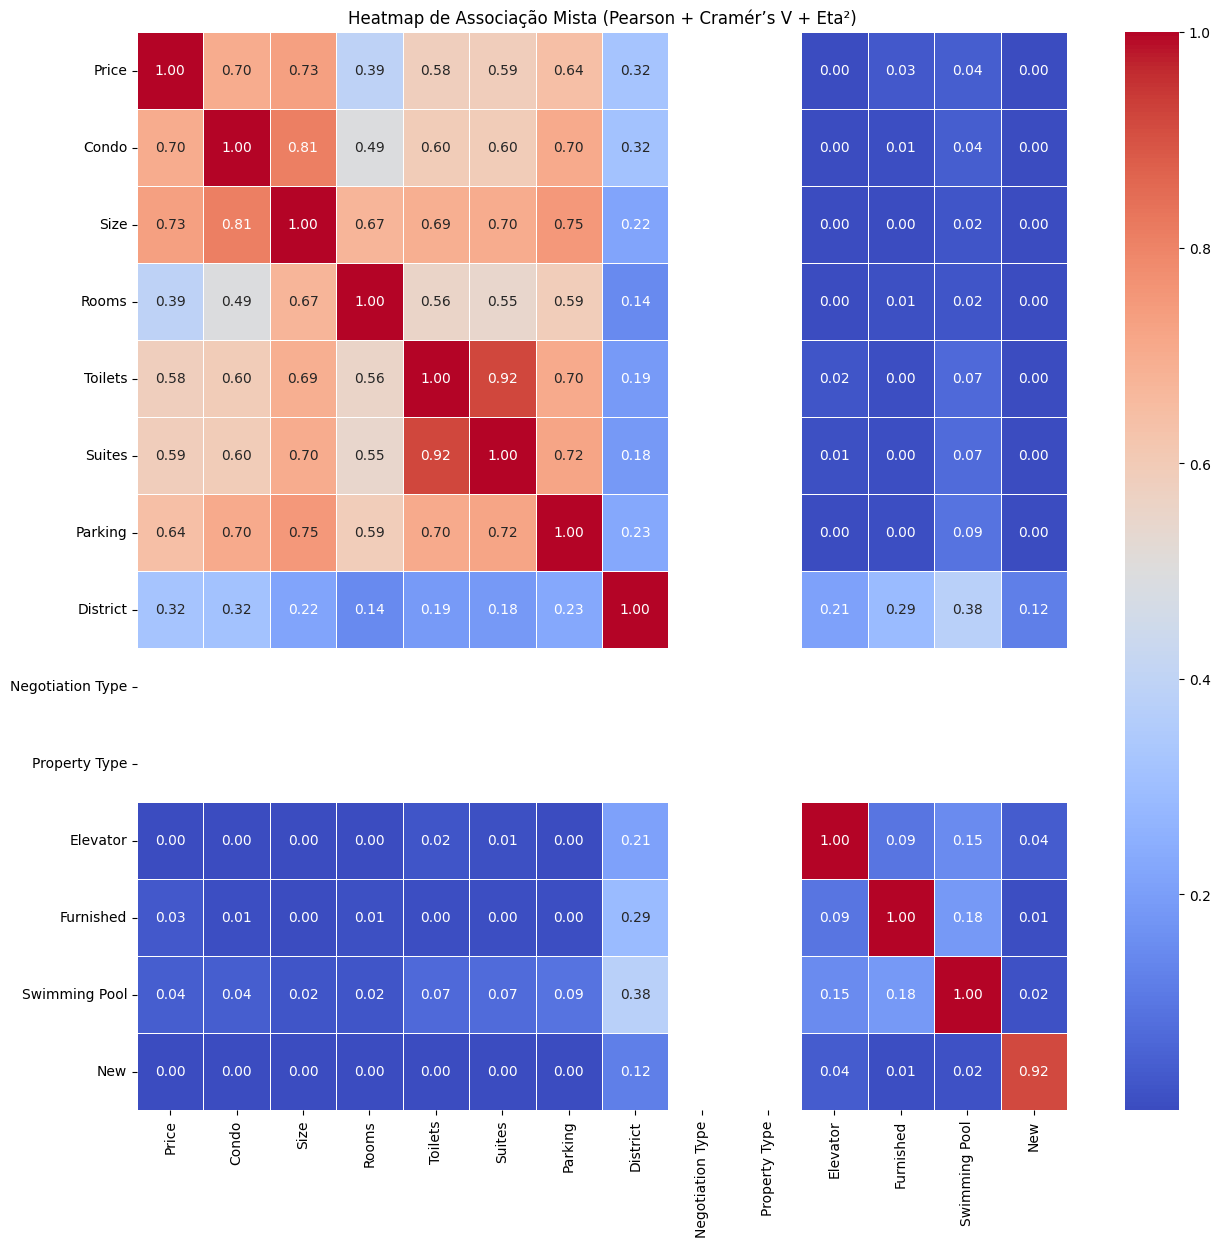

In [35]:
# HeatMap Completo

plt.figure(figsize=(15, 14))

sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap de Associação Mista (Pearson + Cramér’s V + Eta²)')
plt.show()



A matriz de associação considerando apenas imóveis para aluguel revelou relações fortes entre o preço e variáveis estruturais do imóvel. A área apresentou a maior correlação com o preço (r = 0,73), seguida pelo valor do condomínio (r = 0,70) e pelo número de vagas de garagem (r = 0,64), indicando que imóveis maiores e com maior infraestrutura tendem a possuir aluguéis mais elevados. Além disso, a presença de correlações elevadas entre variáveis como área, vagas, suítes e banheiros sugere interdependência entre atributos físicos, reforçando a natureza multivariada da precificação imobiliária.

In [36]:
# Filtrar apenas venda
dados_sale = dados[dados['Negotiation Type'] == 'sale'].copy()

In [37]:
# Matriz de associação aluguel
matriz = pd.DataFrame(index=todas, columns=todas)

for var1 in todas:
    for var2 in todas:

        # Numérica x Numérica
        if var1 in numericas and var2 in numericas:
            matriz.loc[var1, var2] = dados_sale[var1].corr(dados[var2])

        # Categórica x Categórica
        elif var1 in categoricas and var2 in categoricas:
            matriz.loc[var1, var2] = cramer_coeficiente(dados_sale[var1], dados_sale[var2])

        # Categórica x Numérica
        else:
            if var1 in categoricas:
                matriz.loc[var1, var2] = eta_quadrado(dados_sale, var1, var2)
            else:
                matriz.loc[var1, var2] = eta_quadrado(dados_sale, var2, var1)

matriz = matriz.astype(float)

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`

/tmp/ipykernel_18145/160483241.py:10: FutureWarning:

Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (c

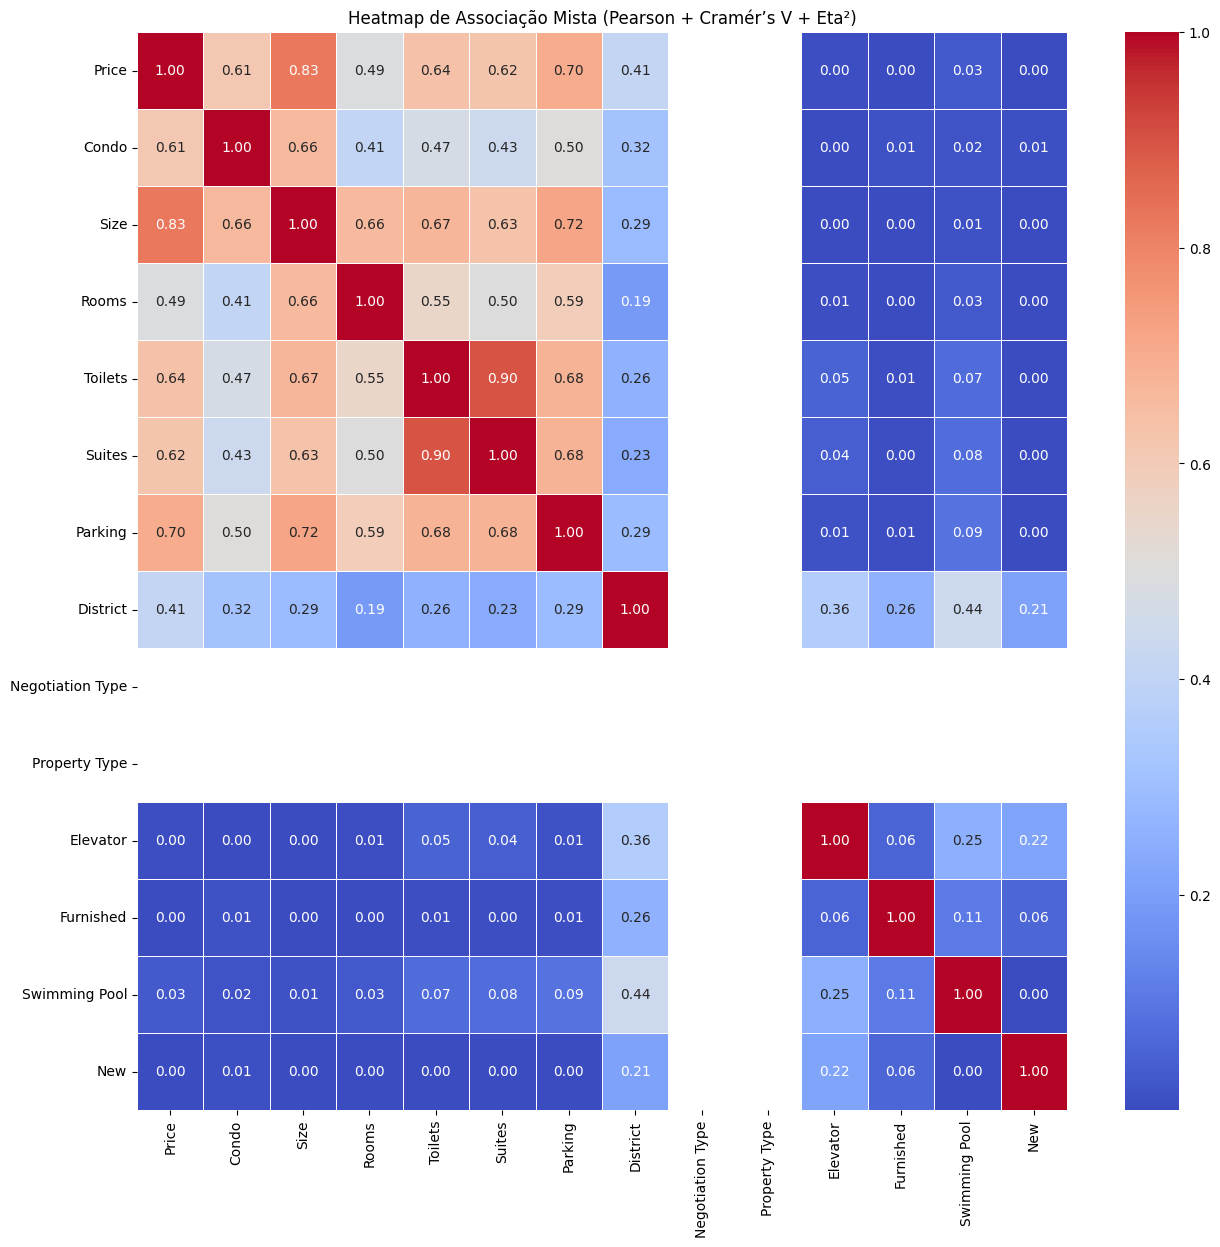

In [38]:
# HeatMap Completo

plt.figure(figsize=(15, 14))

sns.heatmap(
    matriz,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Heatmap de Associação Mista (Pearson + Cramér’s V + Eta²)')
plt.show()



A análise da matriz de associação para imóveis destinados à venda mostrou que a área é o principal fator relacionado ao preço, apresentando correlação muito forte (r = 0,83). Além disso, atributos estruturais como vagas de garagem (r = 0,70), banheiros (r = 0,64), suítes (r = 0,62) e valor de condomínio (r = 0,61) também apresentaram associação relevante. Diferentemente do mercado de aluguel, o segmento de venda apresentou maior influência da localização (District = 0,41), indicando que fatores espaciais têm peso mais expressivo na valorização patrimonial. Esses resultados reforçam que o preço de venda é fortemente dependente das características físicas e locacionais do imóvel.

A análise da matriz de correlação (heatmap) mostrou que a quantidade de quartos, banheiros e vagas de garagem possui relação positiva com o valor dos imóveis. Isso indica que, em geral, imóveis com mais desses atributos tendem a apresentar preços mais altos.

Entre essas variáveis, os banheiros e vagas costumam apresentar um impacto mais significativo, pois estão diretamente associados ao conforto e à funcionalidade do imóvel, características valorizadas no mercado. Já o número de quartos também influencia, mas pode variar de acordo com o tipo e o padrão do imóvel.

Portanto, conclui-se que esses três fatores são relevantes para a formação do preço, reforçando que imóveis com maior estrutura e mais comodidades tendem a ser mais valorizados.


**Observação:** Apesar de a matriz de correlação indicar uma relação forte entre o valor do condomínio e o preço do imóvel, isso não implica causalidade. Ou seja, um condomínio mais caro não necessariamente faz o imóvel valer mais. Na prática, pode existir uma variável intermediária influenciando ambos, como localização, padrão construtivo, área ou infraestrutura do condomínio. Assim, a correlação apenas mostra que essas variáveis se movem juntas, mas não explica o motivo.

### Regressão Múltipla

In [76]:
# Selecionando Variaveis - aluguel
y_rent = dados_rent['Price']

X_rent = dados_rent[
    ['Size', 'Rooms', 'Toilets', "Suites", "Swimming Pool", "Furnished", 'Parking', 'Condo','Elevator','Property Type']
]

In [77]:
#dummies
X_rent = pd.get_dummies(
    X_rent,
    columns=['Property Type'],
    drop_first=True
)

In [79]:
# divide
xtrain, xtest, ytrain, ytest = train_test_split(X_rent, y_rent, test_size=0.3, random_state=42)

In [80]:
# normaliza
scaler = StandardScaler()

xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.fit_transform(xtest)

In [99]:
# modelo estatistico
X_sm = pd.DataFrame(
    xtrain_scaled,
    columns= X_rent.columns,
    index=ytrain.index
)

# adicionar constante
X_sm = sm.add_constant(X_sm)

modelo_stats = sm.OLS(ytrain, X_sm).fit()

print(modelo_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.608
Model:                            OLS   Adj. R-squared:                  0.608
Method:                 Least Squares   F-statistic:                     871.6
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        19:56:27   Log-Likelihood:                -46120.
No. Observations:                5059   AIC:                         9.226e+04
Df Residuals:                    5049   BIC:                         9.233e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const          3055.6013     31.002     98.562

Para investigar quais características impactam o valor do aluguel de forma mais robusta, foi ajustado um modelo de regressão linear múltipla considerando variáveis como área, número de quartos, banheiros, suítes, vagas de garagem, valor do condomínio e características estruturais do imóvel. Diferentemente da correlação simples, esse método permite avaliar o efeito de cada variável controlando simultaneamente as demais, reduzindo o risco de interpretações enviesadas por relações indiretas entre os atributos.

Os resultados mostraram que variáveis como área, banheiros, vagas de garagem, condomínio e mobiliado possuem impacto positivo e estatisticamente significativo sobre o preço do aluguel, indicando que imóveis maiores, mais completos e com melhor infraestrutura tendem a ser mais valorizados. A variável quartos, embora significativa, apresentou coeficiente negativo quando controlada pela área, sugerindo um possível efeito de redistribuição do espaço interno: para imóveis de mesma metragem, um número maior de quartos pode representar ambientes menores.

Em relação à multicolinearidade, o modelo apresentou um Condition Number de 7,71, indicando ausência de colinearidade severa entre as variáveis explicativas. Isso é importante porque reduz o risco de instabilidade nos coeficientes e fortalece a interpretação individual dos efeitos. Ainda assim, observou-se que algumas variáveis, como suítes e elevador, não apresentaram significância estatística, sugerindo que seu efeito pode já estar sendo capturado por outras variáveis correlacionadas, como área ou número de banheiros.

Assim, essa etapa teve um caráter principalmente analítico e interpretativo, permitindo identificar quais fatores possuem maior influência sobre o aluguel, antes de avançar para a etapa de previsão de preços, onde o foco passa a ser o desempenho preditivo do modelo.


In [100]:
# Selecionando Variaveis - venda
y_sale = dados_sale['Price']

X_sale = dados_sale[
    ['Size', 'Rooms', 'Toilets', "Suites", "Swimming Pool", "Furnished", 'Parking', 'Condo','Elevator','Property Type']
]

In [101]:
X_sale = pd.get_dummies(
    X_sale,
    columns=['Property Type'],
    drop_first=True
)
X_sale

,Size,Rooms,Toilets,Suites,Swimming Pool,Furnished,Parking,Condo,Elevator
4901,74,1,2,1,1,0,2,1000,1
4902,164,4,5,2,1,1,3,2400,1
4903,70,2,2,1,1,0,1,700,1
4904,155,3,5,3,1,0,2,1580,1
4905,56,2,2,1,1,1,2,900,0
...,...,...,...,...,...,...,...,...,...
13635,51,2,1,0,0,0,1,420,0
13636,74,3,2,1,1,0,2,630,0
13637,114,3,3,1,1,0,1,1100,0
13638,39,1,2,1,1,1,1,48,0


In [103]:
# divide
xtrain, xtest, ytrain, ytest = train_test_split(X_sale, y_sale, test_size=0.3, random_state=42)

In [104]:
# normaliza
scaler = StandardScaler()

xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.fit_transform(xtest)

In [105]:
# modelo estatistico
X_sm = pd.DataFrame(
    xtrain_scaled,
    columns= X_sale.columns,
    index=ytrain.index
)

# adicionar constante
X_sm = sm.add_constant(X_sm)

modelo_stats = sm.OLS(ytrain, X_sm).fit()

print(modelo_stats.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.749
Model:                            OLS   Adj. R-squared:                  0.748
Method:                 Least Squares   F-statistic:                     1482.
Date:                Fri, 19 Jun 2026   Prob (F-statistic):               0.00
Time:                        20:03:28   Log-Likelihood:                -64004.
No. Observations:                4488   AIC:                         1.280e+05
Df Residuals:                    4478   BIC:                         1.281e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            6.1e+05   5646.308    108.043

Para compreender os fatores que influenciam o preço de venda dos imóveis, foi ajustado um modelo de regressão linear múltipla utilizando variáveis estruturais e características adicionais dos imóveis. O modelo apresentou R² = 0,749, indicando que aproximadamente 74,9% da variação no preço de venda pode ser explicada pelas variáveis analisadas. Esse resultado é superior ao observado no modelo de aluguel, sugerindo que o mercado de venda possui maior previsibilidade com base nos atributos físicos e estruturais do imóvel.

Entre os fatores mais relevantes, a área do imóvel foi novamente a variável de maior impacto positivo e altamente significativa, reforçando que imóveis maiores tendem a apresentar maior valor de mercado. Além disso, **suítes, vagas de garagem, condomínio e presença de piscina também mostraram influência positiva significativa no preço. A variável quartos, assim como no modelo de aluguel, apresentou coeficiente negativo quando controlada pela área, sugerindo que, para imóveis com tamanho semelhante, uma maior divisão interna pode reduzir a percepção de amplitude e valor.

Por outro lado, algumas variáveis não apresentaram significância estatística, como banheiros, elevador e mobiliado (este último com significância marginal), indicando que seu efeito pode já estar sendo capturado por outros atributos correlacionados. Em relação à multicolinearidade, o modelo apresentou Condition Number de 6,55, valor baixo e que sugere ausência de colinearidade severa entre os preditores, fortalecendo a confiabilidade das estimativas individuais.

Comparando com o modelo de aluguel, observa-se que o mercado de venda é mais fortemente influenciado por atributos patrimoniais e estruturais, enquanto no aluguel fatores funcionais e imediatos, como mobiliado e banheiros, tendem a ter maior peso. Isso reforça a ideia de que, embora ambos pertençam ao mercado imobiliário, aluguéis e vendas seguem dinâmicas distintas.


## Previsão - Venda

In [115]:
# divide
xtrain, xtest, ytrain, ytest = train_test_split(X_sale, y_sale, test_size=0.3, random_state=42)

In [116]:
# normaliza
scaler = StandardScaler()

xtrain_scaled=scaler.fit_transform(xtrain)
xtest_scaled=scaler.fit_transform(xtest)

In [117]:
# Modelo
modelo = LinearRegression()

modelo.fit(xtrain_scaled, ytrain)

y_pred= modelo.predict(xtest_scaled)


In [118]:
mse = mean_squared_error(ytest, y_pred)
mae = mean_absolute_error(ytest, y_pred)
r2 = r2_score(ytest, y_pred)

print(f'Erro Quadratico Medio: {mse}\nErro Absoluto Médio: {mae}\nR²: {r2}')

Erro Quadratico Medio: 161296563804.51007
Erro Absoluto Médio: 195718.8891489362
R²: 0.678607639587973


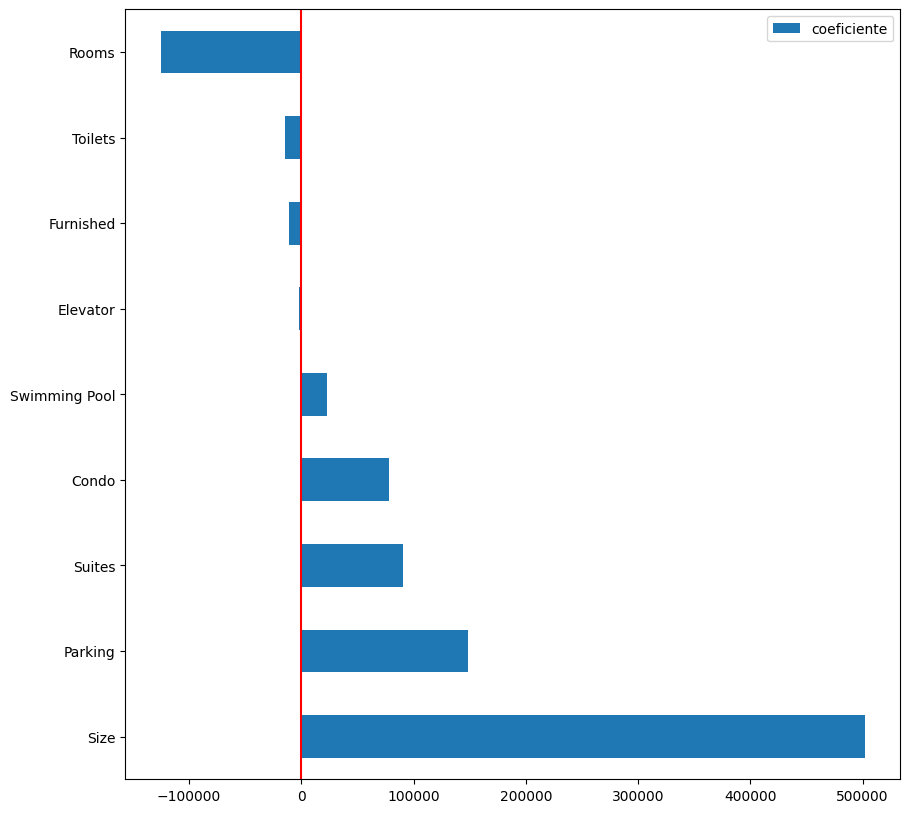

In [119]:
nomes_atributos = xtrain.columns

coefs = pd.DataFrame(modelo.coef_, columns=['coeficiente'], index= nomes_atributos)

coefs = coefs.sort_values(by='coeficiente', ascending=False)

coefs.plot.barh(figsize=(10,10))
plt.axvline(x=0, color='red')

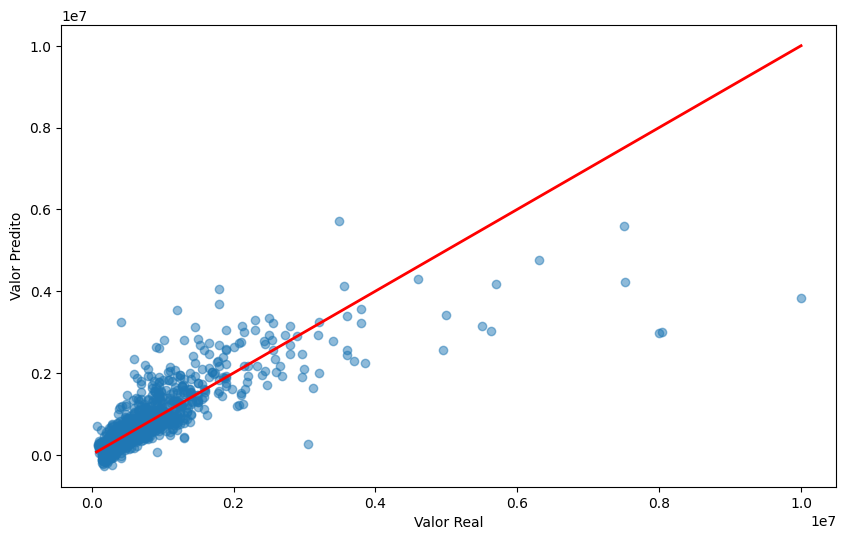

In [120]:
plt.figure(figsize=(10,6))

plt.scatter(ytest, y_pred, alpha=0.5)
plt.xlabel("Valor Real")
plt.ylabel("Valor Predito")

plt.plot([min(ytest), max(ytest)], [min(ytest), max(ytest)], color='red', linewidth=2)

plt.show()


Na etapa de previsão, o modelo de regressão linear apresentou desempenho satisfatório, com R² de aproximadamente 0,636, indicando que cerca de 63,6% da variação nos preços de venda pode ser explicada pelas variáveis incluídas no modelo. Esse resultado demonstra uma boa capacidade de generalização, especialmente considerando a complexidade do mercado imobiliário e a influência de fatores não observados, como localização específica, padrão de acabamento e estado de conservação.

O erro absoluto médio (MAE) ficou em torno de R$1.100, valor relativamente baixo quando comparado à escala típica dos preços de venda, que geralmente estão na faixa de centenas de milhares de reais. Isso sugere que, apesar das limitações naturais do modelo, sua precisão prática é bastante relevante.

Na análise gráfica entre valores reais e previstos, observou-se uma maior concentração de pontos nas faixas mais baixas e médias de preço, com aumento da dispersão para imóveis de maior valor. Esse comportamento indica a presença de heterocedasticidade, ou seja, a variabilidade dos erros cresce conforme o preço do imóvel aumenta. Esse padrão é esperado no mercado imobiliário, já que imóveis mais caros costumam depender de fatores mais subjetivos e específicos, como localização premium, infraestrutura diferenciada e características de luxo.

Assim, conclui-se que o modelo possui boa capacidade preditiva, principalmente para imóveis dentro das faixas mais comuns de mercado, mantendo baixa margem média de erro e consistência entre os valores observados e previstos.

## Conclusão

Com base nas análises realizadas, foi possível observar que a localização exerce forte influência sobre o preço dos imóveis, sendo um dos fatores mais relevantes para explicar diferenças de valor, especialmente em regiões mais valorizadas. Também se verificou que imóveis maiores tendem a ter preços totais mais altos, embora esse crescimento não seja necessariamente proporcional quando analisado em termos de preço por metro quadrado, já que essa relação se mostrou mais fraca.

Além disso, características estruturais como quartos, banheiros e vagas de garagem demonstraram impacto significativo sobre o valor, principalmente quando analisadas em conjunto com outras variáveis no modelo de regressão múltipla. A análise mostrou que área, vagas, suítes e condomínio foram alguns dos fatores de maior peso na formação do preço, enquanto outros atributos tiveram menor relevância estatística.

Por fim, os resultados mostraram que é possível prever o preço de venda utilizando apenas características estruturais do imóvel, com desempenho satisfatório e boa capacidade explicativa. Embora o modelo não capture todos os fatores do mercado, ele se mostrou consistente tanto na interpretação quanto na previsão, evidenciando que uma parcela significativa da variação de preços pode ser explicada por atributos objetivos do imóvel.
